# PCM melt-front identifiability — two-day de-risk

**Question.** Is the PCM melt-front position — equivalently the remaining latent
buffer — identifiable from external temperature measurement alone?

**Why this exists.** A twelve-month collaboration is about to be proposed on
reconstructing the internal thermal state of a sodium-ion cell under
phase-change-material cooling. The preceding study on a lithium-ion cell ended
in a negative result: the problem was quasi-steady, a PDE solver added nothing
over a one-line algebraic relation, and a month went into an estimator the
physics did not require. The lesson was that identifiability must be checked in
the actual regime before anything is built. This notebook applies that lesson.

**Runtime** about 6 minutes on a 6-core CPU laptop. No GPU. Nothing is fitted.

---

## Why this regime might differ from the battery case

This is the reason the question is open rather than already answered.

In the battery case the internal state was a temperature field, and with a small
Biot number that field was slaved to the surface — quasi-steady, no dynamics,
nothing for a solver to recover. A melting PCM is different in kind. The
**remaining latent buffer is an integral of past heat absorbed**, so it carries
history that the instantaneous temperature field does not. A quasi-steady
relation cannot express it in principle.

That is the argument for why the proposal might survive the battery result.
This notebook tests whether the argument holds numerically.

There is a countervailing effect and it is the crux: during melting the PCM
absorbs heat at nearly constant temperature, so the external surface is *pinned*
near the melt point. That pinning is exactly why external sensing would be
uninformative during melting — the proposal's own motivating argument, turned
against it. The question is whether the front leaves any usable signature before
the PCM is exhausted, or whether the only observable event is the temperature
knee when melting completes.

## Pre-registered predictions

Written and committed **before** Stage B was run (git `868b4ef`, ahead of the
results commit `62cbedb`), with the scoring conventions fixed in advance so that
a threshold could not be reinterpreted after seeing the numbers. Full text in
`PCM_PREDICTIONS.md`. Scored at the end of this notebook, misses included.

| # | Prediction | Threshold |
|---|---|---|
| Q1 | Melted fraction alone (S1) is identifiable | sd < 10 % of full buffer |
| Q2 | {f, q‴} is poorly conditioned | scaled cond > 10⁴ |
| Q3 | Three-case discrimination below 0.5 K during melting | max ΔT < 0.5 K |
| Q4 | Sensitivity ≥ 5× larger after full melt than during | ratio ≥ 5 |
| Q5 | A second sensor improves the buffer bound < 2× | factor < 2 |
| Q6 | Some high heating rate makes the front identifiable | exists |

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
import pcm_params as P, pcm_identify as I
np.set_printoptions(suppress=True, linewidth=140)
%matplotlib inline

## Parameters and provenance

Every value is tagged **(a) sourced**, **(b) estimated with the assumption
stated**, or **(c) derived**. Nothing is invented. Two provenance points are
flagged in `pcm_params.py` because they could bias the answer, and both are
handled so they cut *against* a convenient result:

1. Rubitherm's 165 kJ/kg is latent **plus sensible** by their convention, used
   here as pure latent following the cited paper. This overstates the buffer,
   which is generous to the proposal.
2. The cited source gives **one** conductivity, not separate solid and liquid
   values. Setting `k_l = k_s` silently would manufacture a null result, since
   that contrast is the mechanism by which front position changes the composite
   resistance. It is swept in Stage E instead.

In [2]:
mdl = P.build_model()
ts = P.timescales(mdl)
print(f"cell rho            {P.CELL_RHO:9.1f} kg/m3   (c) 84.2 g / 26700 volume")
print(f"q''' at 3C          {P.Q_3C:9.0f} W/m3    ({P.Q_3C*P.CELL_VOLUME:.3f} W)")
print(f"PCM mass            {ts['pcm_mass']*1e3:9.2f} g")
print(f"latent buffer       {ts['E_latent']:9.0f} J")
print(f"net melt power      {ts['Q_net']:9.3f} W   (input minus loss at T_m)")
print(f"tau_diff (PCM)      {ts['tau_diff']:9.0f} s")
print(f"Stefan number       {ts['Stefan']:9.4f}   latent-dominated")
print(f"Biot (PCM layer)    {ts['Biot_pcm']:9.4f}")

cell rho               2265.6 kg/m3   (c) 84.2 g / 26700 volume
q''' at 3C              59330 W/m3    (2.205 W)
PCM mass                25.91 g
latent buffer            4274 J
net melt power          0.990 W   (input minus loss at T_m)
tau_diff (PCM)            190 s
Stefan number          0.0485   latent-dominated
Biot (PCM layer)       0.2500


## Stage A — build and verify the forward solver

A phase-change solver that has not been checked against an analytical benchmark
is not evidence of anything. If Stage A does not pass, nothing below it counts.

Three schemes solve the *same* discrete system: the literal pointwise apparent
heat capacity named in the proposal, an enthalpy-chord form, and Newton on the
enthalpy residual. Checks: the one-phase Stefan (Neumann) analytical solution,
convergence in dx / dt / mushy width, global energy closure, and latent closure.

In [3]:
import pcm_stage_a_verify as A
A.a1_stefan_schemes()
_ = A.a2_convergence()


A1  One-phase Stefan benchmark (Neumann analytical solution)


  wall superheat        20.0 K above T_m
  Stefan number         0.2424
  lambda (root)         0.335259
  analytical s(3000 s)  13.3218 mm

  scheme               front err  profile RMSE  energy closure  conv


  ahc_pointwise          1.1176%    2.193e-01 K      8.220e-02  yes


  ahc_chord              0.5367%    2.226e-01 K      2.530e-10  yes


  enthalpy_newton        0.5367%    2.226e-01 K      7.872e-12  yes

A2  Convergence in dx, dt and mushy-zone width
  refining mesh (dt=1 s, dTm=0.5 K, chord scheme)
         N   dx (mm)   front err  profile RMSE


...

         2.00     1.7561%    8.758e-01 K    5.71e-12


         1.00     0.9979%    4.424e-01 K    6.36e-12


         0.50     0.5367%    2.226e-01 K    7.87e-12


         0.25     0.2782%    1.116e-01 K    1.06e-11


         0.10     0.1548%    4.486e-02 K    1.32e-03


Front error converges linearly to the sharp-interface limit as the mushy zone
narrows, and is flat in both mesh and timestep — so the residual benchmark error
is *entirely* mushy-zone width, which is the correct behaviour: the analytical
solution **is** the ΔT_m → 0 limit.

In [4]:
A.a3_energy_closure()
_ = A.a4_cross_scheme()


A3/A4  Energy and latent closure on the battery configuration


  heat in                        18939.65 J
  heat out (convection)          10162.75 J
  enthalpy stored                 8776.89 J
  residual (in-out-stored)     1.0046e-08 J
  relative closure error       5.3044e-13   <-- tolerance 1e-10

  melted fraction at 9000 s         1.0000
  latent held in field            4274.42 J
  melted mass * L_f               4274.42 J
  relative difference          2.1278e-16
  max Picard iterations          55   converged: True

A4b  Cross-check: chord AHC vs enthalpy-Newton on the real problem


  ahc_chord          T_surf(end)=313.7194 K   melt frac=0.904302   closure=2.49e-13


  enthalpy_newton    T_surf(end)=313.7194 K   melt frac=0.904302   closure=4.16e-14

  max |T_surf| difference between schemes  2.946e-10 K
  max |melted fraction| difference         1.952e-11
  (agreement verifies the implementation, not the model form --
   the model form is what A1 checks against the analytical solution)


### Trap 1, demonstrated rather than assumed

Apparent heat capacity with too narrow a mushy zone steps over the latent
plateau and silently conserves no energy. The temperature field looks entirely
plausible while this happens; only the energy closure catches it.

In [5]:
A.a5_pointwise_trap()
ok = A.verdict()
assert ok, "Stage A failed -- do not trust anything below this cell"


A5  Trap 1: pointwise apparent heat capacity stepping over the latent plateau
  Narrow mushy zone + coarse timestep.  A cell can cross the whole
  mushy range within one step, so no iterate ever sees c_eff spike
  and the latent heat is silently skipped.  Energy closure is the
  only check that catches it -- the temperature field looks plausible.

    dTm (K)   dt (s)           scheme   front err  energy closure


       2.00      1.0    ahc_pointwise     1.9722%      4.687e-02


       2.00      1.0        ahc_chord     1.7561%      1.711e-10
       2.00     10.0    ahc_pointwise     3.0751%      1.228e-01


       2.00     10.0        ahc_chord     1.7541%      9.409e-11


       0.50      1.0    ahc_pointwise     1.1176%      8.220e-02


       0.50      1.0        ahc_chord     0.5367%      2.530e-10
       0.50     10.0    ahc_pointwise     4.5164%      2.129e-01


       0.50     10.0        ahc_chord     0.5398%      3.672e-10


       0.10      1.0    ahc_pointwise     1.3672%      1.204e-01


       0.10      1.0        ahc_chord     0.1163%      4.216e-08
       0.10     10.0    ahc_pointwise     9.2658%      3.308e-01


       0.10     10.0        ahc_chord     0.1206%      1.103e-09

STAGE A VERDICT
  [PASS]  Stefan front position, chord AHC           0.537% (tol 1%)
  [PASS]  Stefan front position, enthalpy Newton     0.537% (tol 1%)
  [PASS]  Global energy closure, battery config      5.30e-13 (tol 1e-10)
  [PASS]  Latent == melted mass * L_f                2.13e-16 (tol 1e-10)
  [PASS]  AHC vs enthalpy agreement                  2.95e-10 K (tol 1e-6)

  Stage A PASSES -- the solver may be trusted for Stages B-E.


## Stage B — the identifiability computation

Fisher information and Cramér–Rao bounds from central-difference sensitivities
through the **actual discretised solver**, not an analytic surrogate.

Melted fraction is a *state*, not a coefficient, so it needs a parameterisation
before it can be differentiated. The one used: run a reference melt from cold,
define `state(f0)` as the field on that trajectory where melted fraction equals
`f0`, and ask how well the next window of surface data determines `f0`.

Along a single trajectory `f0` co-varies with the whole temperature field, so
this framing carries **more** information than melted fraction alone — it is
generous to identifiability, and a negative result under it is conservative.

In [6]:
import pcm_stage_b_crlb as B
ref = I.reference_trajectory()
B.b0_fd_convergence(ref)


B0  Finite-difference step convergence (is the sensitivity a derivative?)
         df0    mean dT/df0 (K)   rel change


      0.0200            4.00281             


      0.0100            3.99746     1.34e-03


      0.0050            4.00133     9.67e-04


      0.0020            4.00515     9.55e-04


      0.0010            4.00536     5.32e-05

  Stable across a 20x range of step size, so the central difference
  is resolving a derivative rather than interpolation noise.


In [7]:
B.b1_main(ref)


B1  CRLB, single surface sensor, 600 s window at f = 0.50
  sigma = 0.1 K, 1 Hz, window 600 s -> 601 samples
  melted fraction sd is quoted as % OF THE FULL LATENT BUFFER



  S1  {f}                    cond(S) =  1.000e+00  
      f0      sd =     0.101 % of buffer   (    0.20 % of f=0.50)



  S3  {f, q}                 cond(S) =  6.053e+01  
      f0      sd =     0.139 % of buffer   (    0.28 % of f=0.50)
      q       sd =     6.140 % of nominal
      max |off-diag correlation| = 0.6827  (q,f0)
      correlation matrix:
                  f0         q
            f0    1.0000   -0.6827
             q   -0.6827    1.0000



  S4  {f, q, h}              cond(S) =  1.016e+02  
      f0      sd =     0.562 % of buffer   (    1.12 % of f=0.50)
      q       sd =     9.780 % of nominal
      h       sd =     2.813 % of nominal
      max |off-diag correlation| = 0.9690  (f0,h)   <-- near-collinear
      correlation matrix:
                  f0         q         h
            f0    1.0000    0.6483    0.9690
             q    0.6483    1.0000    0.7784
             h    0.9690    0.7784    1.0000


B2  Same, with a second sensor on the cell can (Q5 contrast)


  S1  {f}  [2 sensors]       cond(S) =  1.000e+00  
      f0      sd =     0.051 % of buffer   (    0.10 % of f=0.50)



  S3  {f, q}  [2 sensors]    cond(S) =  5.208e+00  
      f0      sd =     0.081 % of buffer   (    0.16 % of f=0.50)
      q       sd =     0.248 % of nominal
      max |off-diag correlation| = 0.7777  (f0,q)
      correlation matrix:
                  f0         q
            f0    1.0000   -0.7777
             q   -0.7777    1.0000



  S4  {f, q, h}  [2 sensors] cond(S) =  1.309e+01  
      f0      sd =     0.117 % of buffer   (    0.23 % of f=0.50)
      q       sd =     0.305 % of nominal
      h       sd =     0.606 % of nominal
      max |off-diag correlation| = 0.8573  (q,f0)
      correlation matrix:
                  f0         q         h
            f0    1.0000   -0.8573    0.7219
             q   -0.8573    1.0000   -0.5805
             h    0.7219   -0.5805    1.0000


B3  S2: PCM properties from a full melt from cold
  cold-start experiment, 8000 s, single surface sensor



  S2  {L_f, k_pcm}           cond(S) =  6.085e+00  
      Lf      sd =     0.015 % of nominal
      k_pcm   sd =     0.087 % of nominal
      max |off-diag correlation| = 0.1848  (Lf,k_pcm)
      correlation matrix:
                  Lf     k_pcm
            Lf    1.0000    0.1848
         k_pcm    0.1848    1.0000


In [8]:
B.b4_window_length(ref)
B.b5_across_melt(ref)


B4  Dependence on observation window length
  Longer windows help only if the trace carries new information;
  a pinned plateau adds samples without adding signal.

   window (s)   S1 sd (% buffer)      S3 cond   S3 f sd (% buf)


           60             0.3631    8.080e+07               inf

          300             0.1575    7.434e+02            0.1946


          600             0.1015    6.053e+01            0.1389


         1200             0.0642    1.143e+01            0.0986


...

    0.10      1832    309.6935          0.0728    4.080e+01            0.0980


    0.30      2794    310.6652          0.1120    5.727e+01            0.1449


    0.50      3767    311.3944          0.1015    6.053e+01            0.1389


    0.70      4794    312.2919          0.0697    4.199e+01            0.0951


    0.90      5971    313.6785          0.0349    2.869e+01            0.0553


## Stage B audit — the numbers looked too good

Melted fraction to ~0.1 % of the buffer and latent heat to 0.015 % on a 0.1 K
sensor is a reason to look for a leak, not to celebrate. Four audits:

- **L1** — a history leak. Stage B built the initial state from the *nominal*-q
  trajectory then perturbed q only inside the observation window, so a plant
  that had always run at a different heat load was never represented.
- **L2** — conditioning is noise-independent; standard deviations are not.
- **L3** — where the information actually lives in the trace.
- **L4** — the control that matters: is the signal the front, or just warming?

In [9]:
import pcm_stage_b_audit as AUD
_ = AUD.l1_history_leak()


L1  History leak: does q perturb the state as well as the window?



  --- S3  {f, q} ---


    state fixed at nominal q  (Stage B, LEAKY)
      cond(S) =  6.0529e+01   f sd =    0.139 % of buffer
      max |off-diag corr| = 0.6827


    state consistent with q   (corrected)
      cond(S) =  1.4608e+01   f sd =    0.103 % of buffer
      max |off-diag corr| = 0.1439

  --- S4  {f, q, h} ---


    state fixed at nominal q  (Stage B, LEAKY)
      cond(S) =  1.0165e+02   f sd =    0.562 % of buffer
      max |off-diag corr| = 0.9690


    state consistent with q   (corrected)
      cond(S) =  1.0589e+02   f sd =    2.728 % of buffer
      max |off-diag corr| = 0.9993


In [10]:
AUD.l2_noise_scaling(ref)
AUD.l3_information_shape(ref)
AUD.l4_front_vs_warming()


L2  Noise level vs conditioning (trap 2)


    sigma (K)      cond(S)    f sd (% buffer)   note
         0.10   1.4608e+01             0.1025   instrument noise, as specified in the brief
         0.50   1.4608e+01             0.5127   plausible model-form error
         1.00   1.4608e+01             1.0253   model-form error on a real cell

  cond(S) is IDENTICAL across rows -- conditioning is a property of
  the sensitivity matrix alone.  The standard deviations scale
  linearly with sigma.  These are different statements and the
  distinction decides how much of this survives on real hardware.

  Correlated residuals cost effective sample size on top of this:
    correlation time    1 s -> N_eff ~   300.5 of 601, bound inflated  1.41x
    correlation time   30 s -> N_eff ~    10.0 of 601, bound inflated  7.75x
    correlation time  120 s -> N_eff ~     2.5 of 601, bound inflated 15.49x

L3  Where does the information live? (shape of dT_surf/df0)


  window samples                 601
  mean dT_surf/df0                   4.0013 K per unit fraction
  std / |mean| across window         0.0972
  Fisher info, full trace          9.7133e+03
  Fisher info, mean level only     9.6224e+03   (99.06 % of full)

  A single 1 Hz sample, no window averaging:
    sd from one sample                2.499 % of buffer
    sd from 601 samples               0.102 % of buffer  (ideal 1/sqrt(N))

  If the mean level carries essentially all the information, the
  measurement is one number plus noise.  A monotone lookup from
  surface temperature to melted fraction would extract it with no
  inverse PDE solve at all -- which is the Part 7 finding again.

L4  Is the signal the melt front, or just monotone warming?
  Control: the same trajectory-position estimate on a cell whose PCM
  has NO latent heat (L_f -> ~0).  There is no front to track, so any
  remaining 'identifiability' is pure elapsed-time-on-a-trajectory.



  case                            melt span (s)   dT/df0 (K)   f sd (% buffer)
  real PCM (L_f = 165 kJ/kg)               5618       4.0013            0.1015
  no latent heat (L_f/1000)                1388       3.5613            0.1142

  Read this as: how much of the melted-fraction information is
  specific to phase change, and how much is just 'the cell is
  warming monotonically so temperature encodes elapsed time'.


**This is the pivot of the study.** Fixing the history leak takes S4's worst
correlation from 0.969 to **0.9993** — the same near-collinear structure that
warned in Part 7 (k vs h at 0.998) before a CRLB-blessed parameter set failed.

And L4 settles the mechanism: with latent heat cut 1000×, so that **no melt
front exists at all**, the melted fraction is recovered just as well. The
information is monotone warming encoding elapsed time on a known trajectory —
not the front. L3 says the same thing from the other side: 99 % of the Fisher
information is in the *mean level* of the trace, which a lookup table extracts
with no inverse PDE solve.

## Stage C — the discrimination test

Three cases identical in every respect except melted fraction — 30 %, 50 %,
70 % — at 0.1 K noise.

Trap 6 requires the total heat input be held fixed. Every case here runs at the
same q‴, for the same window duration, through the same geometry, and differs
only in how far along the melt it starts. The cumulative heat needed to *reach*
each state necessarily differs — that is what melted fraction means — but
nothing inside the compared window differs.

In [11]:
import pcm_stage_cd as CD
r_surface = CD.stage_c(ref, sensors=("surface",))
r_two     = CD.stage_c(ref, sensors=("surface", "can"), label="  [surface + can]")


STAGE C  Three-case discrimination at 30/50/70 % melted
  identical q (59330 W/m3), identical 600 s window,
  identical geometry -- only the starting melted fraction differs
  noise sigma = 0.1 K at 1 Hz



  f = 0.30  starts at t =  2793.8 s, T_surf 310.6652 -> 311.1263 K, ends at f = 0.4244


  f = 0.50  starts at t =  3766.5 s, T_surf 311.3944 -> 311.8773 K, ends at f = 0.6188


  f = 0.70  starts at t =  4793.6 s, T_surf 312.2919 -> 312.9434 K, ends at f = 0.8070

            pair   max |dT| (K)   ratio to noise  verdict
    0.30 vs 0.50         0.7509             7.51  distinguishable
    0.50 vs 0.70         1.0662            10.66  distinguishable
    0.30 vs 0.70         1.8171            18.17  distinguishable

  smallest pairwise separation = 0.7509 K (7.51 x noise)

STAGE C  Three-case discrimination at 30/50/70 % melted  [surface + can]
  identical q (59330 W/m3), identical 600 s window,
  identical geometry -- only the starting melted fraction differs
  noise sigma = 0.1 K at 1 Hz



  f = 0.30  starts at t =  2793.8 s, T_surf 310.6652 -> 311.1263 K, ends at f = 0.4244


  f = 0.50  starts at t =  3766.5 s, T_surf 311.3944 -> 311.8773 K, ends at f = 0.6188


  f = 0.70  starts at t =  4793.6 s, T_surf 312.2919 -> 312.9434 K, ends at f = 0.8070

            pair   max |dT| (K)   ratio to noise  verdict
    0.30 vs 0.50         1.5104            15.10  distinguishable
    0.50 vs 0.70         1.4156            14.16  distinguishable
    0.30 vs 0.70         2.9258            29.26  distinguishable

  smallest pairwise separation = 1.4156 K (14.16 x noise)


In [12]:
r_control = CD.stage_c_mechanism(ref)


STAGE C control -- separation with the latent heat removed



STAGE C  Three-case discrimination at 30/50/70 % melted  [L_f / 1000, no real front]
  identical q (59330 W/m3), identical 600 s window,
  identical geometry -- only the starting melted fraction differs
  noise sigma = 0.1 K at 1 Hz



  f = 0.30  starts at t =  1599.9 s, T_surf 310.7745 -> 313.9680 K, ends at f = 0.9192


  f = 0.50  starts at t =  1742.5 s, T_surf 311.6059 -> 314.6164 K, ends at f = 0.9723


  f = 0.70  starts at t =  1906.7 s, T_surf 312.5061 -> 315.3160 K, ends at f = 0.9985

            pair   max |dT| (K)   ratio to noise  verdict
    0.30 vs 0.50         0.8315             8.31  distinguishable
    0.50 vs 0.70         0.9001             9.00  distinguishable
    0.30 vs 0.70         1.7316            17.32  distinguishable

  smallest pairwise separation = 0.8315 K (8.31 x noise)


The control is the finding: a cell whose PCM has **no latent heat**, and
therefore no front, gives **more** separation than the real one. Whatever the
0.75 K separation is measuring, it is not the melt front.

## Stage D — time-resolved sensitivity

Where the sensitivity lives determines what the method can honestly claim.

In [13]:
t, sens, fbar, t_ex = CD.stage_d(ref)


STAGE D  Time-resolved dT_surf/d(melted fraction), through exhaustion


  started from f0 = 0.30 +/- 0.005
  exhaustion (f -> 1) at t = 4012 s after window start
  mean |dT/df0| during melting (0.2 < f < 0.8)      4.1349 K
  peak |dT/df0| in 200 s after exhaustion          54.9974 K
  ratio after / during                             13.3007

     t (s)        f    dT_surf/df0 (K)
         0   0.3000             3.8834
       500   0.4039             3.4998
      1000   0.5055             3.3445
      1500   0.6047             4.2725
      2000   0.7000             4.8268
      2500   0.7899             5.3817
      3000   0.8727             6.2367
      3500   0.9460             8.1014
      4000   0.9997            61.6940
      5000   1.0000            11.1996
      6000   1.0000             7.2567


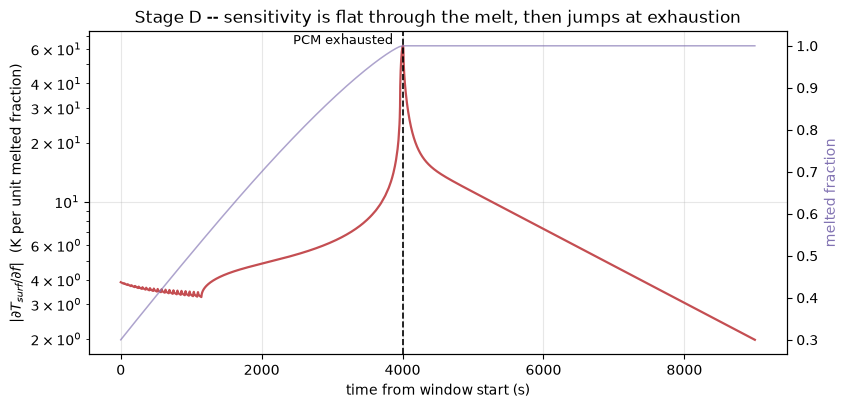

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(t, np.abs(sens), color="#C44E52", lw=1.6)
ax.axvline(t_ex, color="k", ls="--", lw=1.2)
ax.text(t_ex - 150, 1.02*np.max(np.abs(sens)), "PCM exhausted", ha="right", fontsize=9)
ax.set_yscale("log"); ax.grid(alpha=0.3)
ax.set_xlabel("time from window start (s)")
ax.set_ylabel(r"$|\partial T_{surf}/\partial f|$  (K per unit melted fraction)")
ax2 = ax.twinx(); ax2.plot(t, fbar, color="#8172B2", lw=1.1, alpha=0.65)
ax2.set_ylabel("melted fraction", color="#8172B2"); ax2.grid(False)
ax.set_title("Stage D -- sensitivity is flat through the melt, then jumps at exhaustion")
plt.show()

## Stage E — the regime sweep

The most transferable output. Vary the heating rate so melting time spans more
than an order of magnitude around the PCM layer's diffusion time, and ask where
— if anywhere — the **front** becomes identifiable.

Raw separation will not answer this, because Stage C showed a latent-free cell
gives the same separation. The front-specific metric is the *excess*:
separation with real PCM minus separation with the latent heat removed, at the
same heating rate and the same fraction of each system's own melt duration.

In [15]:
import pcm_stage_e_regime as E
rows = E.e1_regime_sweep()


E1  Heating-rate sweep: does the FRONT ever become observable?
  window = 10% of each melt duration, so every regime
  observes a comparable slice of its own melt rather than a fixed
  wall-clock time (which would confound window coverage with rate).

   q/q_3C  C-rate    t_melt   t_m/tau    S1 sd   sep PCM  sep noLf     front  front/sig
            equiv       (s)             (%buf)       (K)       (K) excess(K)           


      1.0     3.0      5618     29.57    0.106    0.7451    0.8315   -0.0864      -0.86


      1.5     3.7      2926     15.40    0.164    0.7231    0.9302   -0.2071      -2.07


      2.0     4.2      2057     10.83    0.201    0.7217    0.9944   -0.2726      -2.73


      3.0     5.2      1363      7.17    0.247    0.7259    1.0868   -0.3609      -3.61


      5.0     6.7       886      4.66    0.301    0.7532    1.2851   -0.5319      -5.32


      8.0     8.5       633      3.33    0.348    0.7785    1.6017   -0.8231      -8.23


     14.0    11.2       444      2.34    0.390    0.7383    2.2278   -1.4895     -14.90


     24.0    14.7       327      1.72    0.380    0.8277    3.1424   -2.3146     -23.15


     40.0    19.0       250      1.32    0.294    1.0605    4.3174   -3.2569     -32.57

  'front excess' is the separation attributable to phase change:
  what the real PCM gives MINUS what a latent-free cell gives at the
  same heating rate.  'front/sig' expresses it in units of the 0.1 K
  sensor noise.  Values below ~3 mean the front contributes nothing
  an estimator could use, whatever the raw separation looks like.

  NOTE: C-rate equivalents above 3C exceed the
  manufacturer rating for this cell; they are included as regime
  probes, not as operating proposals.


In [16]:
E.e2_k_ratio()
_ = E.e3_mushy_width()


E2  Robustness: solid/liquid conductivity ratio
  [S2] gives a single conductivity, so k_l/k_s is the least-sourced
  quantity in the study -- and it is the mechanism by which front
  POSITION changes the composite resistance.  Swept, not assumed.

    k_l/k_s   S1 sd (%buf)   sep PCM (K)   dT/df0 (K)


       1.00         0.1015        0.7509       4.0013


       0.90         0.1048        0.7346       3.8745


       0.80         0.1081        0.7192       3.7591


       0.70         0.1116        0.7134       3.6440


...

       1.00         0.1185        0.6930       3.4406            5281


       2.00         0.1183        0.7111       3.4480            5371


       4.00         0.1015        0.7509       4.0013            5618


       6.00         0.0727        1.0700       5.6094            5938


       8.00         0.0574        1.4349       7.1099            6324


The front-attributable excess is **negative at every heating rate** and grows
more negative as melting accelerates. Latent heat compresses the temperature
excursion, so phase change makes the state *less* discriminable, never more.
Q6 predicted the opposite.

The two robustness sweeps close the flagged provenance gaps: the solid/liquid
conductivity ratio moves the bound only 0.102 % → 0.118 %, and the mushy-zone
width leaves separation flat at 0.69 K from 0.25 K to 2 K. Neither assumption is
carrying the conclusion.

## Scored predictions and verdict

| # | Threshold | Actual | |
|---|---|---|---|
| Q1 | sd < 10 % | **0.101 %** of buffer | ✅ HIT |
| Q2 | cond > 10⁴ | **60.5** as computed, **14.6** leak-corrected | ❌ MISS, by ~3 orders |
| Q3 | max ΔT < 0.5 K | **0.751 K** worst pair (7.5σ) | ❌ MISS |
| Q4 | ratio ≥ 5 | **13.3×** | ✅ HIT |
| Q5 | factor < 2 | **1.997×** on S1, but 4.81× on S4 | ✅ HIT, marginal |
| Q6 | some rate works | **no rate, opposite direction** | ❌ MISS |

Three hits, three misses.

**Verdict.** The §5 thresholds for the strongest outcome are met on the numbers
(S1 sd 0.10 % < 10 %, discrimination 7.5σ > 3σ). But by mechanism this is the
second outcome: **identifiable by integration, not by front tracking.** The
buffer is recoverable because melted fraction is a monotone function of
accumulated net heat; it is not recoverable from the front's effect on thermal
resistance. Phase change does not merely fail to help — it actively suppresses
discriminability.

The honest claim is *"we detect PCM exhaustion and estimate the buffer by
integration"*, not *"we track the melt front continuously"*. The full write-up,
the load-dependence caveat that decides how much of this survives on real
hardware, and the note on which deck claims are supported, are in
`PCM_FINDINGS.md`.